# HLS-CMDS Heart and Lung Sound Dataset

**References:**
- [Dataset Paper](https://doi.org/10.17632/8972jxbpmp.1)
- [GitHub Source Code](https://github.com/Torabiy/HLS-CMDS)


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import numpy as np
from scipy import signal
from IPython.display import Audio, display


## Load and Inspect Metadata

In [2]:
# Load metadata CSV files
hs_csv = 'HLS-CMDS_dataset/HS.csv'
ls_csv = 'HLS-CMDS_dataset/LS.csv'
mix_csv = 'HLS-CMDS_dataset/Mix.csv'

hs_df = pd.read_csv(hs_csv)
ls_df = pd.read_csv(ls_csv)
mix_df = pd.read_csv(mix_csv)

hs_df['filename'] = hs_df['Heart Sound ID'] + '.wav'
hs_df['path'] = os.path.join('HLS-CMDS_dataset/HS/HS', '') + hs_df['filename']

ls_df['filename'] = ls_df['Lung Sound ID'] + '.wav'
ls_df['path'] = os.path.join('HLS-CMDS_dataset/LS/LS', '') + ls_df['filename']

mix_df['filename'] = mix_df['Mixed Sound ID'] + '.wav'
mix_df['path'] = os.path.join('HLS-CMDS_dataset/Mix/Mix', '') + mix_df['filename']

print('Heart Sounds Metadata:')
display(hs_df.head())
print('Lung Sounds Metadata:')
display(ls_df.head())
print('Mixed Sounds Metadata:')
display(mix_df.head())

Heart Sounds Metadata:


,Gender,Heart Sound Type,Location,Heart Sound ID,filename,path
0,F,Normal,RC,F_N_RC,F_N_RC.wav,HLS-CMDS_dataset/HS/HS/F_N_RC.wav
1,F,Normal,LC,F_N_LC,F_N_LC.wav,HLS-CMDS_dataset/HS/HS/F_N_LC.wav
2,M,Normal,RUSB,M_N_RUSB,M_N_RUSB.wav,HLS-CMDS_dataset/HS/HS/M_N_RUSB.wav
3,F,Normal,LUSB,F_N_LUSB,F_N_LUSB.wav,HLS-CMDS_dataset/HS/HS/F_N_LUSB.wav
4,F,Normal,LLSB,F_N_LLSB,F_N_LLSB.wav,HLS-CMDS_dataset/HS/HS/F_N_LLSB.wav


Lung Sounds Metadata:


,Gender,Lung Sound Type,Location,Lung Sound ID,filename,path
0,M,Normal,RUA,M_N_RUA,M_N_RUA.wav,HLS-CMDS_dataset/LS/LS/M_N_RUA.wav
1,F,Normal,LUA,F_N_LUA,F_N_LUA.wav,HLS-CMDS_dataset/LS/LS/F_N_LUA.wav
2,F,Normal,RMA,F_N_RMA,F_N_RMA.wav,HLS-CMDS_dataset/LS/LS/F_N_RMA.wav
3,F,Normal,LMA,F_N_LMA,F_N_LMA.wav,HLS-CMDS_dataset/LS/LS/F_N_LMA.wav
4,M,Normal,RLA,M_N_RLA,M_N_RLA.wav,HLS-CMDS_dataset/LS/LS/M_N_RLA.wav


Mixed Sounds Metadata:


,Gender,Heart Sound Type,Lung Sound Type,Location,Heart Sound ID,Lung Sound ID,Mixed Sound ID,filename,path
0,F,Late Systolic Murmur,Rhonchi,LUSB,H0001,L0001,M0001,M0001.wav,HLS-CMDS_dataset/Mix/Mix/M0001.wav
1,F,S3,Normal,RLA,H0002,L0002,M0002,M0002.wav,HLS-CMDS_dataset/Mix/Mix/M0002.wav
2,M,Atrial Fibrillation,Normal,LMA,H0003,L0003,M0003,M0003.wav,HLS-CMDS_dataset/Mix/Mix/M0003.wav
3,F,S3,Coarse Crackles,Apex,H0004,L0004,M0004,M0004.wav,HLS-CMDS_dataset/Mix/Mix/M0004.wav
4,M,AV Block,Fine Crackles,RUSB,H0005,L0005,M0005,M0005.wav,HLS-CMDS_dataset/Mix/Mix/M0005.wav


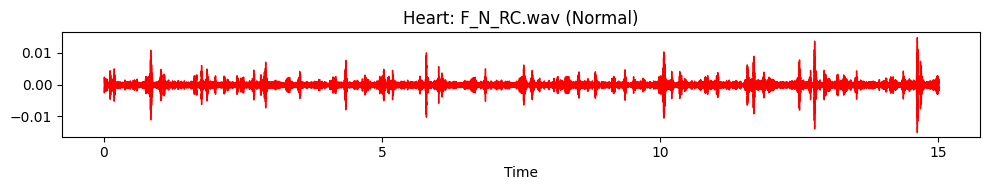

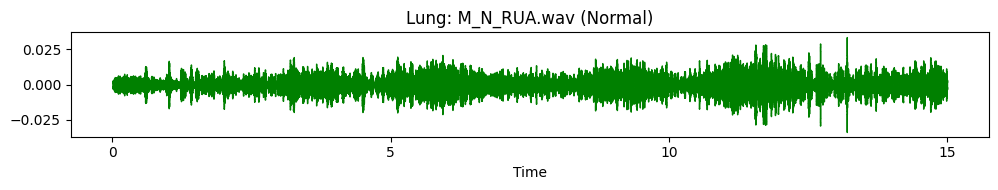

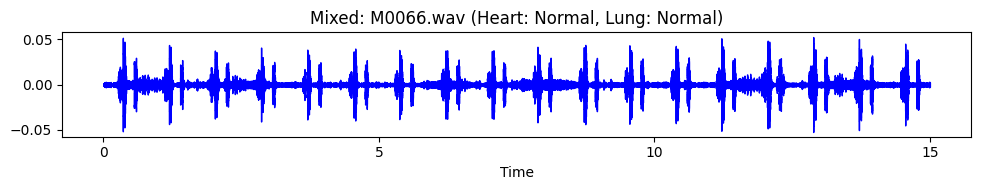

In [3]:
# Heart
heart_row = hs_df.iloc[0]
heart_path = heart_row['path']
heart_audio, sr_heart = librosa.load(heart_path, sr=None)
plt.figure(figsize=(10, 2))
librosa.display.waveshow(heart_audio, sr=sr_heart, color='r')
plt.title(f"Heart: {heart_row['filename']} ({heart_row['Heart Sound Type']})")
plt.tight_layout()
plt.show()
display(Audio(heart_audio, rate=sr_heart))

# Lung
lung_row = ls_df.iloc[0]
lung_path = lung_row['path']
lung_audio, sr_lung = librosa.load(lung_path, sr=None)
plt.figure(figsize=(10, 2))
librosa.display.waveshow(lung_audio, sr=sr_lung, color='g')
plt.title(f"Lung: {lung_row['filename']} ({lung_row['Lung Sound Type']})")
plt.tight_layout()
plt.show()
display(Audio(lung_audio, rate=sr_lung))

# Mixed
mixed_row = mix_df.iloc[65] # 65 is a healthy example
mixed_path = mixed_row['path']
mixed_audio, sr_mixed = librosa.load(mixed_path, sr=None)
plt.figure(figsize=(10, 2))
librosa.display.waveshow(mixed_audio, sr=sr_mixed, color='b')
plt.title(f"Mixed: {mixed_row['filename']} (Heart: {mixed_row['Heart Sound Type']}, Lung: {mixed_row['Lung Sound Type']})")
plt.tight_layout()
plt.show()
display(Audio(mixed_audio, rate=sr_mixed))

## Dataset Structure and Sound Type Definitions

The dataset is organized into three main folders:
- **Mix/**: Mixed heart and lung sounds
- **HS/**: Heart sounds
- **LS/**: Lung sounds

Each folder contains .wav files for different sound types and anatomical points. The sound type codes and their meanings are:

**Heart Sound Types:**
- NH: Normal Heart
- LDM: Late Diastolic Murmur
- MSM: Mid Systolic Murmur
- LSM: Late Systolic Murmur
- AF: Atrial Fibrillation
- S4: Fourth Heart Sound
- ESM: Early Systolic Murmur
- S3: Third Heart Sound
- T: Tachycardia
- AVB: Atrioventricular Block

**Lung Sound Types:**
- NL: Normal Lung
- W: Wheezing
- C: Crackles
- R: Rhonchi
- PR: Pleural Rub
- G: Gurgling

Heart CSV columns: ['Gender', 'Heart Sound Type', 'Location', 'Heart Sound ID', 'filename', 'path']
Lung CSV columns: ['Gender', 'Lung Sound Type', 'Location', 'Lung Sound ID', 'filename', 'path']
Mixed CSV columns: ['Gender', 'Heart Sound Type', 'Lung Sound Type', 'Location', 'Heart Sound ID', 'Lung Sound ID', 'Mixed Sound ID', 'filename', 'path']


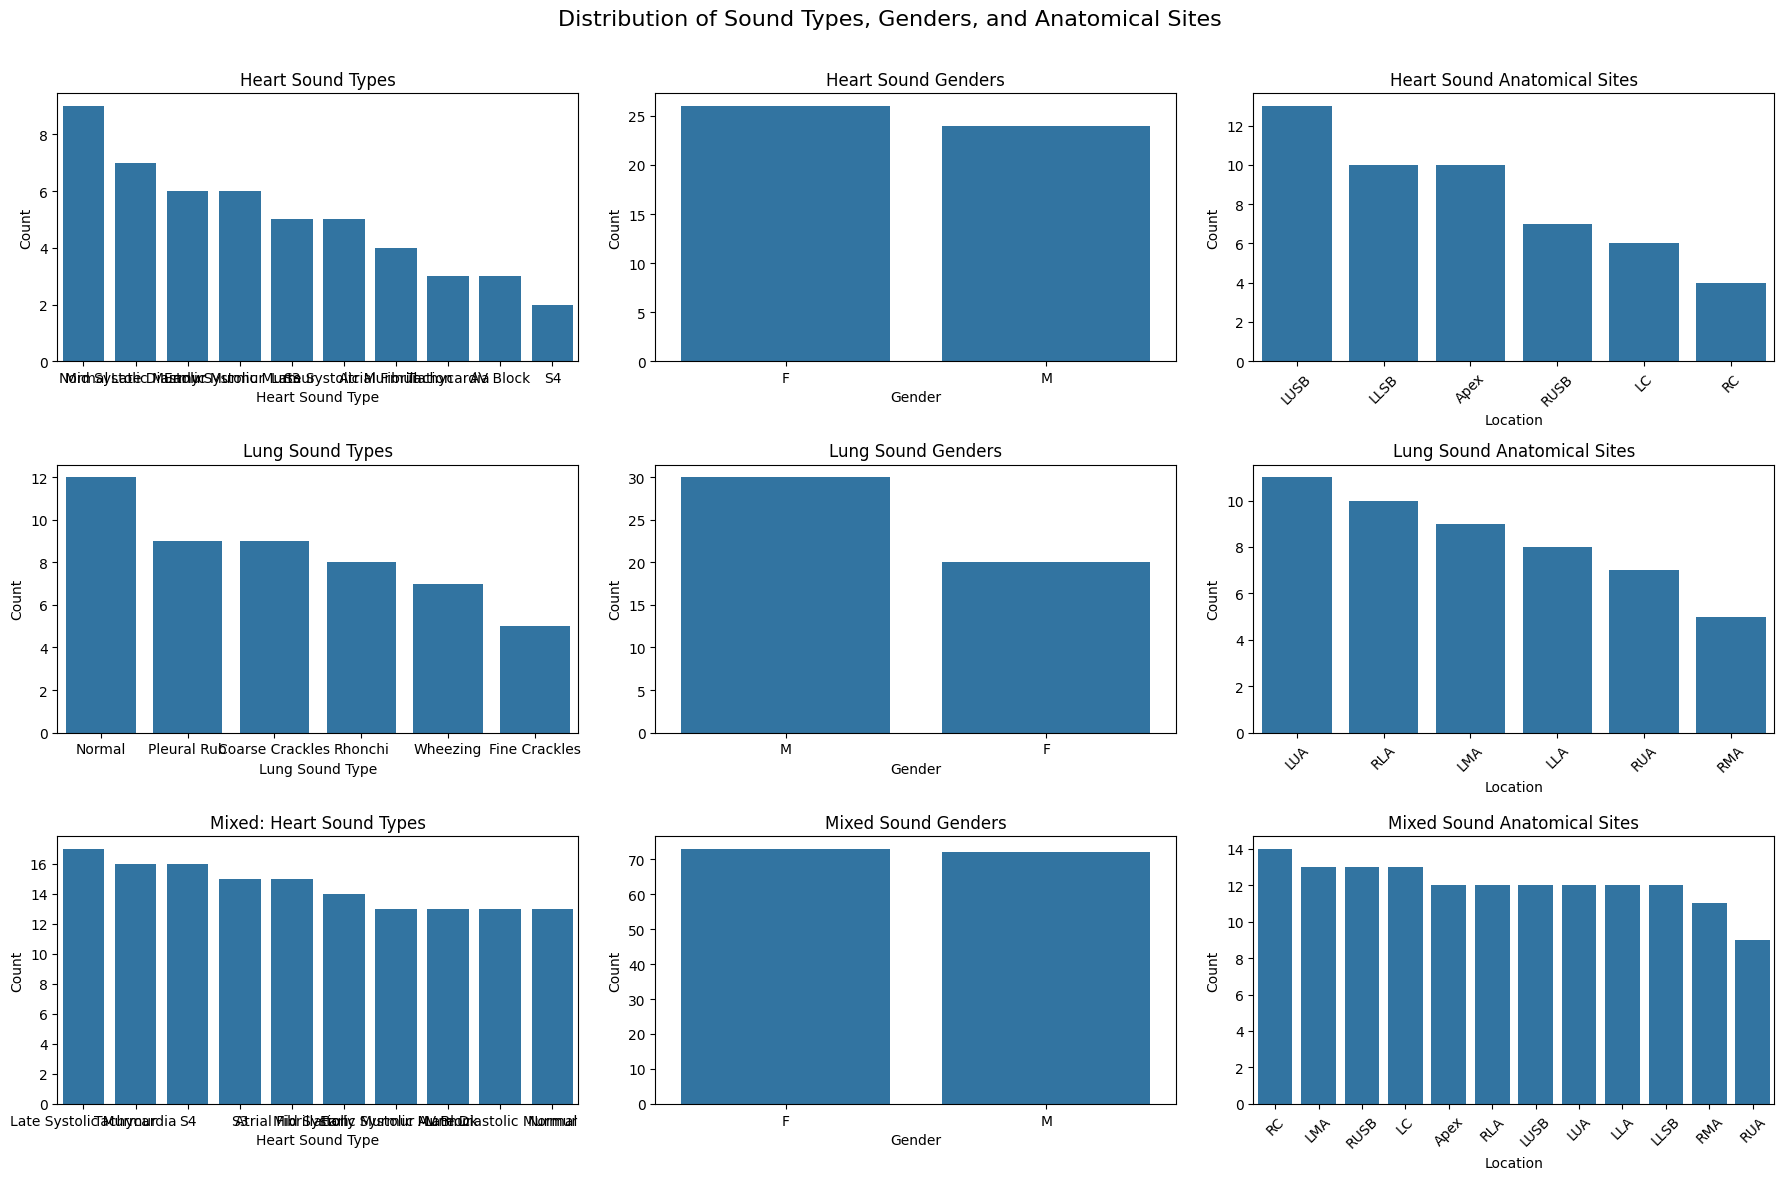

In [4]:
print("Heart CSV columns:", hs_df.columns.tolist())
print("Lung CSV columns:", ls_df.columns.tolist())
print("Mixed CSV columns:", mix_df.columns.tolist())

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Distribution of Sound Types, Genders, and Anatomical Sites', fontsize=16)

# Heart Sounds
ds = hs_df
sns.countplot(ax=axes[0,0], data=ds, x='Heart Sound Type', order=ds['Heart Sound Type'].value_counts().index)
axes[0,0].set_title('Heart Sound Types')
axes[0,0].set_ylabel('Count')

sns.countplot(ax=axes[0,1], data=ds, x='Gender', order=ds['Gender'].value_counts().index)
axes[0,1].set_title('Heart Sound Genders')
axes[0,1].set_ylabel('Count')

sns.countplot(ax=axes[0,2], data=ds, x='Location', order=ds['Location'].value_counts().index)
axes[0,2].set_title('Heart Sound Anatomical Sites')
axes[0,2].set_ylabel('Count')
axes[0,2].tick_params(axis='x', rotation=45)

# Lung Sounds
ds = ls_df
sns.countplot(ax=axes[1,0], data=ds, x='Lung Sound Type', order=ds['Lung Sound Type'].value_counts().index)
axes[1,0].set_title('Lung Sound Types')
axes[1,0].set_ylabel('Count')

sns.countplot(ax=axes[1,1], data=ds, x='Gender', order=ds['Gender'].value_counts().index)
axes[1,1].set_title('Lung Sound Genders')
axes[1,1].set_ylabel('Count')

sns.countplot(ax=axes[1,2], data=ds, x='Location', order=ds['Location'].value_counts().index)
axes[1,2].set_title('Lung Sound Anatomical Sites')
axes[1,2].set_ylabel('Count')
axes[1,2].tick_params(axis='x', rotation=45)

# Mixed Sounds
ds = mix_df
sns.countplot(ax=axes[2,0], data=ds, x='Heart Sound Type', order=ds['Heart Sound Type'].value_counts().index)
axes[2,0].set_title('Mixed: Heart Sound Types')
axes[2,0].set_ylabel('Count')

sns.countplot(ax=axes[2,1], data=ds, x='Gender', order=ds['Gender'].value_counts().index)
axes[2,1].set_title('Mixed Sound Genders')
axes[2,1].set_ylabel('Count')

sns.countplot(ax=axes[2,2], data=ds, x='Location', order=ds['Location'].value_counts().index)
axes[2,2].set_title('Mixed Sound Anatomical Sites')
axes[2,2].set_ylabel('Count')
axes[2,2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [5]:
print("Mixed Sounds DataFrame shape:", mix_df.shape)
print("Columns:", mix_df.columns.tolist())
display(mix_df.head())

print("Unique Heart Sound Types in Mixed:", mix_df['Heart Sound Type'].unique())
print("Unique Lung Sound Types in Mixed:", mix_df['Lung Sound Type'].unique())

print("Gender distribution in Mixed:")
print(mix_df['Gender'].value_counts())
print("\nAnatomical site distribution in Mixed:")
print(mix_df['Location'].value_counts())

Mixed Sounds DataFrame shape: (145, 9)
Columns: ['Gender', 'Heart Sound Type', 'Lung Sound Type', 'Location', 'Heart Sound ID', 'Lung Sound ID', 'Mixed Sound ID', 'filename', 'path']


,Gender,Heart Sound Type,Lung Sound Type,Location,Heart Sound ID,Lung Sound ID,Mixed Sound ID,filename,path
0,F,Late Systolic Murmur,Rhonchi,LUSB,H0001,L0001,M0001,M0001.wav,HLS-CMDS_dataset/Mix/Mix/M0001.wav
1,F,S3,Normal,RLA,H0002,L0002,M0002,M0002.wav,HLS-CMDS_dataset/Mix/Mix/M0002.wav
2,M,Atrial Fibrillation,Normal,LMA,H0003,L0003,M0003,M0003.wav,HLS-CMDS_dataset/Mix/Mix/M0003.wav
3,F,S3,Coarse Crackles,Apex,H0004,L0004,M0004,M0004.wav,HLS-CMDS_dataset/Mix/Mix/M0004.wav
4,M,AV Block,Fine Crackles,RUSB,H0005,L0005,M0005,M0005.wav,HLS-CMDS_dataset/Mix/Mix/M0005.wav


Unique Heart Sound Types in Mixed: ['Late Systolic Murmur' 'S3' 'Atrial Fibrillation' 'AV Block'
 'Tachycardia' 'Early Systolic Murmur' 'Mid Systolic Murmur' 'S4'
 'Late Diastolic Murmur' 'Normal']
Unique Lung Sound Types in Mixed: ['Rhonchi' 'Normal' 'Coarse Crackles' 'Fine Crackles' 'Pleural Rub'
 'Wheezing']
Gender distribution in Mixed:
Gender
F    73
M    72
Name: count, dtype: int64

Anatomical site distribution in Mixed:
Location
RC      14
LMA     13
RUSB    13
LC      13
Apex    12
RLA     12
LUSB    12
LUA     12
LLA     12
LLSB    12
RMA     11
RUA      9
Name: count, dtype: int64


Sample 1: M0001.wav | Heart: Late Systolic Murmur | Lung: Rhonchi | Location: LUSB


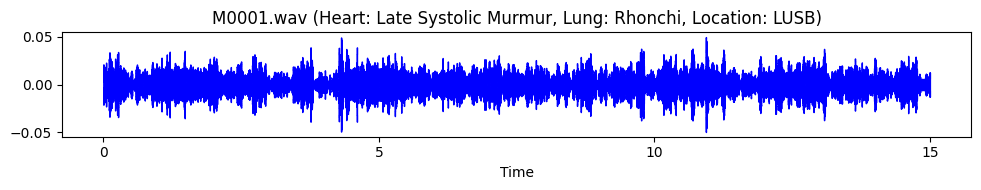

Sample 2: M0002.wav | Heart: S3 | Lung: Normal | Location: RLA


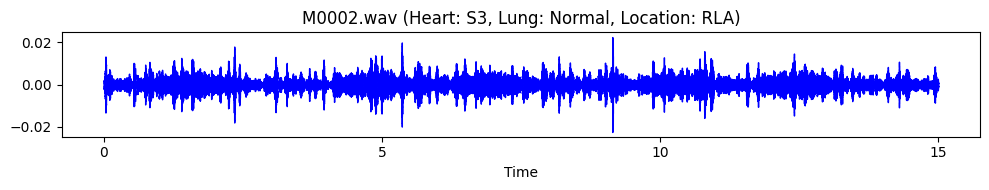

Sample 3: M0003.wav | Heart: Atrial Fibrillation | Lung: Normal | Location: LMA


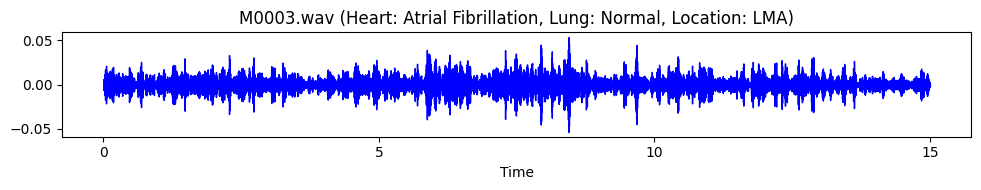

Sample 4: M0004.wav | Heart: S3 | Lung: Coarse Crackles | Location: Apex


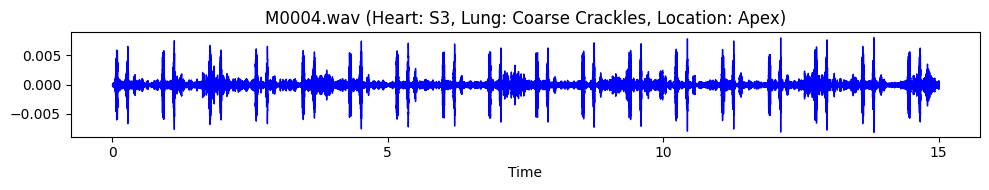

In [6]:
n_examples = 4  # number of samples
for i in range(n_examples):
    row = mix_df.iloc[i]
    audio, sr = librosa.load(row['path'], sr=None)
    print(f"Sample {i+1}: {row['filename']} | Heart: {row['Heart Sound Type']} | Lung: {row['Lung Sound Type']} | Location: {row['Location']}")
    plt.figure(figsize=(10, 2))
    librosa.display.waveshow(audio, sr=sr, color='b')
    plt.title(f"{row['filename']} (Heart: {row['Heart Sound Type']}, Lung: {row['Lung Sound Type']}, Location: {row['Location']})")
    plt.tight_layout()
    plt.show()
    display(Audio(audio, rate=sr))

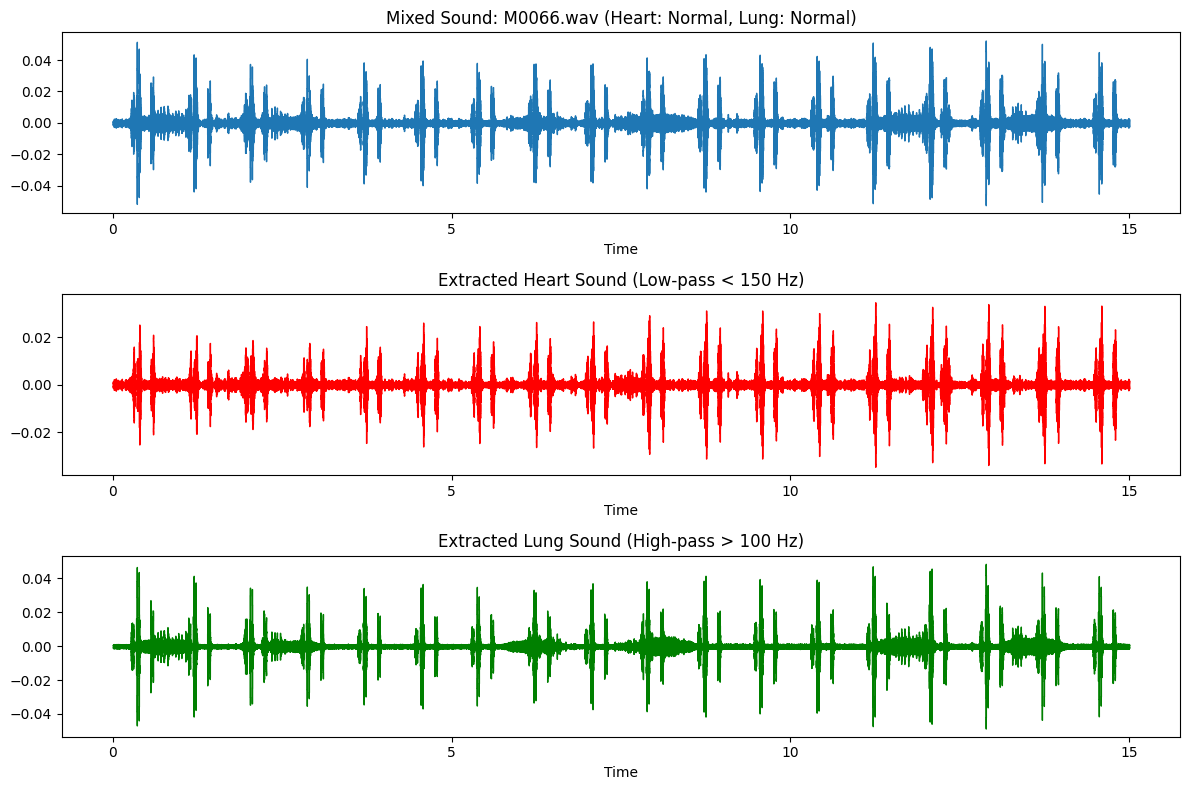

Original Mixed Audio:


Separated Heart Sound:


Separated Lung Sound:


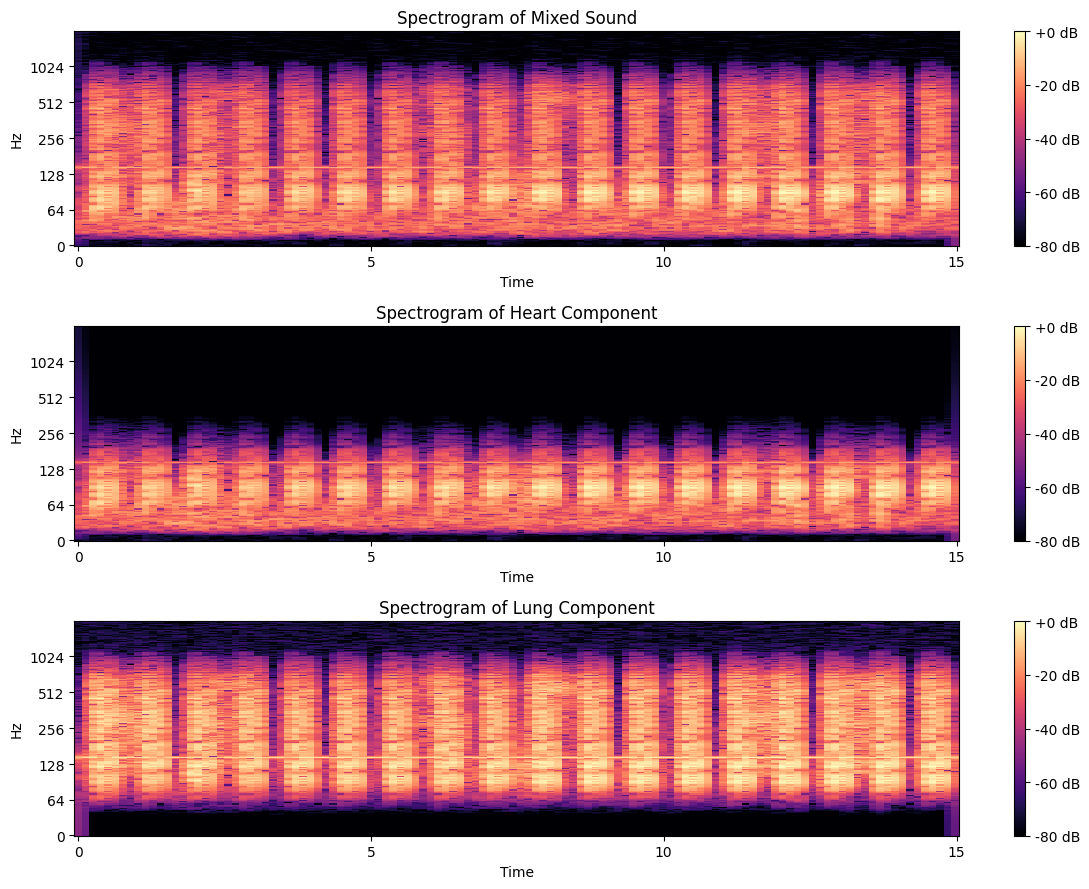

In [7]:
sample_idx = 65 # mixed sound sample, the healthy one
mixed_sound = mix_df.iloc[sample_idx]
audio_path = mixed_sound['path']
mixed_audio, sr = librosa.load(audio_path, sr=None)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
librosa.display.waveshow(mixed_audio, sr=sr)
plt.title(f"Mixed Sound: {mixed_sound['filename']} (Heart: {mixed_sound['Heart Sound Type']}, Lung: {mixed_sound['Lung Sound Type']})")

# Filters for heart sounds (low pass) and lung sounds (high pass)
# Heart sounds are typically below 150 Hz
# Lung sounds typically range from 100-2000 Hz
nyquist = sr / 2.0
heart_cutoff = 150 / nyquist
lung_cutoff = 100 / nyquist

# Butterworth filters
heart_filter_order = 4
lung_filter_order = 4
b_heart, a_heart = signal.butter(heart_filter_order, heart_cutoff, btype='low')
b_lung, a_lung = signal.butter(lung_filter_order, lung_cutoff, btype='high')

heart_separated = signal.filtfilt(b_heart, a_heart, mixed_audio)
lung_separated = signal.filtfilt(b_lung, a_lung, mixed_audio)

plt.subplot(3, 1, 2)
librosa.display.waveshow(heart_separated, sr=sr, color='r')
plt.title(f"Extracted Heart Sound (Low-pass < {heart_cutoff*nyquist:.0f} Hz)")

plt.subplot(3, 1, 3)
librosa.display.waveshow(lung_separated, sr=sr, color='g')
plt.title(f"Extracted Lung Sound (High-pass > {lung_cutoff*nyquist:.0f} Hz)")

plt.tight_layout()
plt.show()

print("Original Mixed Audio:")
display(Audio(mixed_audio, rate=sr))
print("Separated Heart Sound:")
display(Audio(heart_separated, rate=sr))
print("Separated Lung Sound:")
display(Audio(lung_separated, rate=sr))

# Visualizing spectrograms
plt.figure(figsize=(12, 9))

plt.subplot(3, 1, 1)
D = librosa.amplitude_to_db(np.abs(librosa.stft(mixed_audio)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Spectrogram of Mixed Sound")

plt.subplot(3, 1, 2)
D_heart = librosa.amplitude_to_db(np.abs(librosa.stft(heart_separated)), ref=np.max)
librosa.display.specshow(D_heart, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Spectrogram of Heart Component")

plt.subplot(3, 1, 3)
D_lung = librosa.amplitude_to_db(np.abs(librosa.stft(lung_separated)), ref=np.max)
librosa.display.specshow(D_lung, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Spectrogram of Lung Component")

plt.tight_layout()
plt.show()

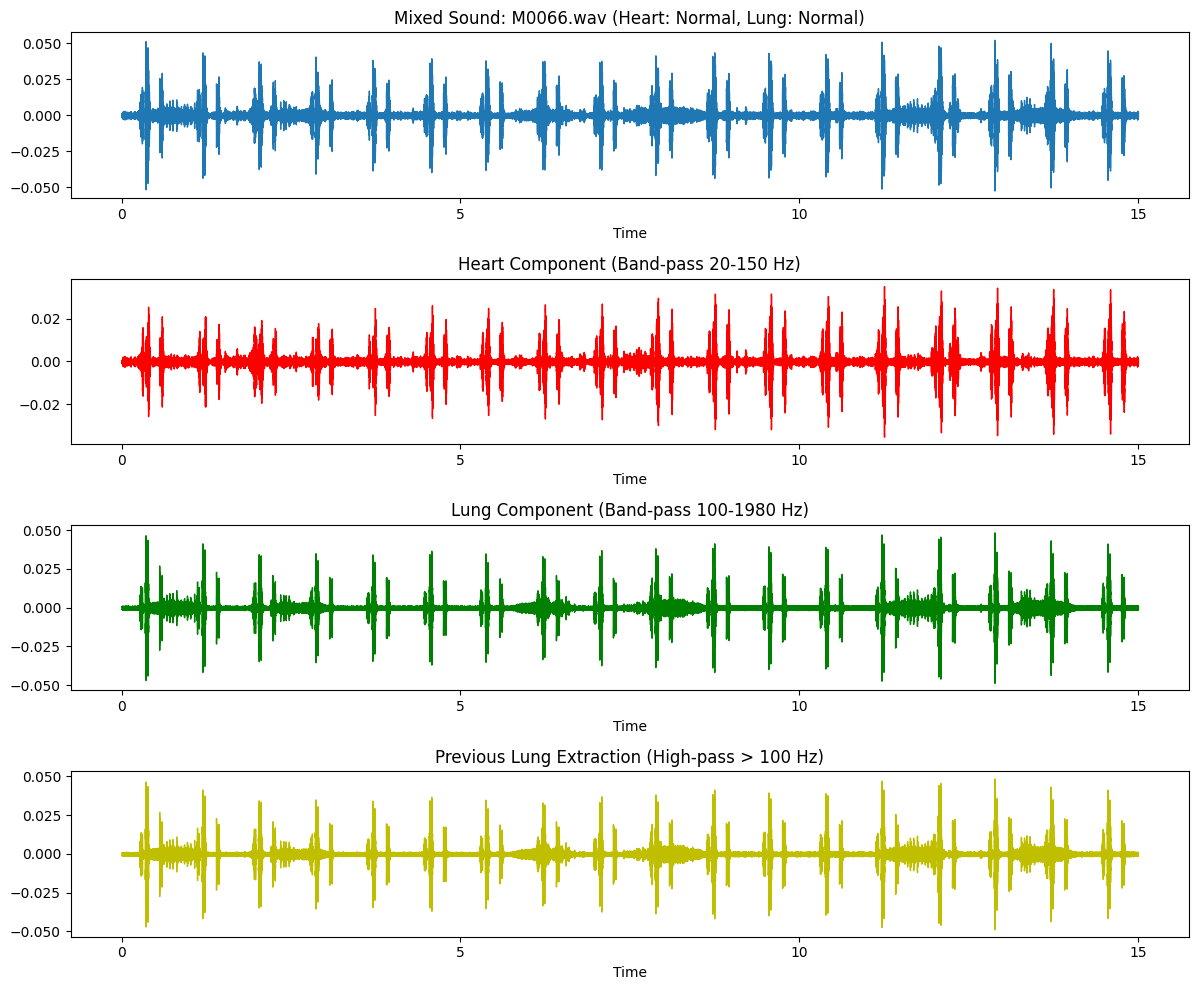

Original Mixed Audio:


Heart Component (Band-pass):


Lung Component (Band-pass):


Previous Lung Extraction (High-pass):


In [8]:
# same healthy example
mixed_sound = mix_df.iloc[sample_idx]
audio_path = mixed_sound['path']
mixed_audio, sr = librosa.load(audio_path, sr=None)

plt.figure(figsize=(12, 10))
plt.subplot(4, 1, 1)
librosa.display.waveshow(mixed_audio, sr=sr)
plt.title(f"Mixed Sound: {mixed_sound['filename']} (Heart: {mixed_sound['Heart Sound Type']}, Lung: {mixed_sound['Lung Sound Type']})")

nyquist = sr / 2.0
heart_low = 20 / nyquist
heart_high = 150 / nyquist

filter_order = 4
lung_low = 100 / nyquist
lung_high = min(0.99, 2000 / nyquist)
b_lung, a_lung = signal.butter(filter_order, [lung_low, lung_high], btype='bandpass')

b_heart, a_heart = signal.butter(filter_order, [heart_low, heart_high], btype='bandpass')
b_lung, a_lung = signal.butter(filter_order, [lung_low, lung_high], btype='bandpass')

heart_separated = signal.filtfilt(b_heart, a_heart, mixed_audio)
lung_separated = signal.filtfilt(b_lung, a_lung, mixed_audio)

plt.subplot(4, 1, 2)
librosa.display.waveshow(heart_separated, sr=sr, color='r')
plt.title(f"Heart Component (Band-pass {heart_low*nyquist:.0f}-{heart_high*nyquist:.0f} Hz)")

plt.subplot(4, 1, 3)
librosa.display.waveshow(lung_separated, sr=sr, color='g')
plt.title(f"Lung Component (Band-pass {lung_low*nyquist:.0f}-{lung_high*nyquist:.0f} Hz)")

previous_heart_cutoff = 150 / nyquist
previous_lung_cutoff = 100 / nyquist
b_heart_old, a_heart_old = signal.butter(4, previous_heart_cutoff, btype='low')
b_lung_old, a_lung_old = signal.butter(4, previous_lung_cutoff, btype='high')
lung_old = signal.filtfilt(b_lung_old, a_lung_old, mixed_audio)

plt.subplot(4, 1, 4)
librosa.display.waveshow(lung_old, sr=sr, color='y')
plt.title(f"Previous Lung Extraction (High-pass > {previous_lung_cutoff*nyquist:.0f} Hz)")

plt.tight_layout()
plt.show()

# Display audio
print("Original Mixed Audio:")
display(Audio(mixed_audio, rate=sr))
print("Heart Component (Band-pass):")
display(Audio(heart_separated, rate=sr))
print("Lung Component (Band-pass):")
display(Audio(lung_separated, rate=sr))
print("Previous Lung Extraction (High-pass):")
display(Audio(lung_old, rate=sr))

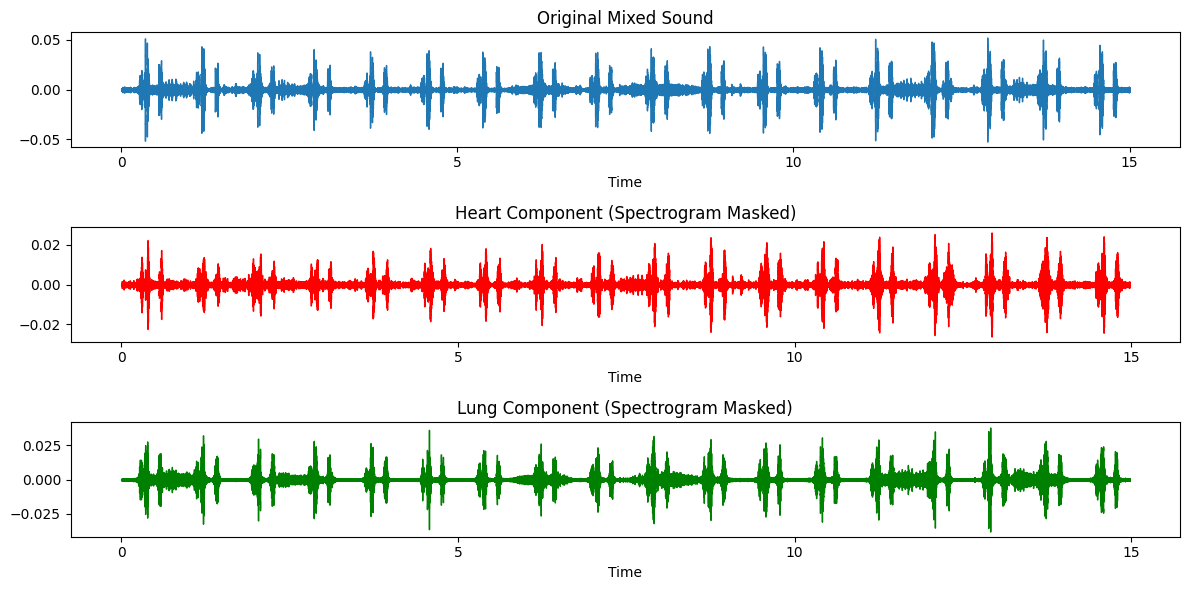

Heart Component (playback):


Lung Component (playback):


In [9]:
# Compute magnitude spectrogram
S = np.abs(librosa.stft(mixed_audio, n_fft=2048, hop_length=256))

# Get heart and lung masks from your band-pass filtered signals
S_heart = np.abs(librosa.stft(heart_separated, n_fft=2048, hop_length=256))
S_lung = np.abs(librosa.stft(lung_separated, n_fft=2048, hop_length=256))

# Soft masks
mask_heart = S_heart / (S_heart + S_lung + 1e-8)
mask_lung = S_lung / (S_heart + S_lung + 1e-8)

# Apply masks to the mixed spectrogram
S_heart_masked = S * mask_heart
S_lung_masked = S * mask_lung

# Griffin-Lim to reconstruct time-domain signals
y_heart_masked = librosa.griffinlim(S_heart_masked, hop_length=256, n_iter=64)
y_lung_masked = librosa.griffinlim(S_lung_masked, hop_length=256, n_iter=64)

# Plot
plt.figure(figsize=(12, 6))
plt.subplot(3,1,1)
librosa.display.waveshow(mixed_audio, sr=sr)
plt.title("Original Mixed Sound")
plt.subplot(3,1,2)
librosa.display.waveshow(y_heart_masked, sr=sr, color='r')
plt.title("Heart Component (Spectrogram Masked)")
plt.subplot(3,1,3)
librosa.display.waveshow(y_lung_masked, sr=sr, color='g')
plt.title("Lung Component (Spectrogram Masked)")
plt.tight_layout()
plt.show()

print("Heart Component (playback):")
display(Audio(y_heart_masked, rate=sr))
print("Lung Component (playback):")
display(Audio(y_lung_masked, rate=sr))


## Using Wavelets

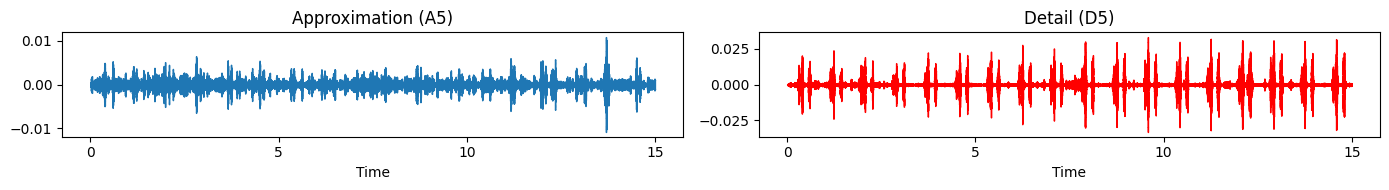

Approximation (A5):


Detail (D5):


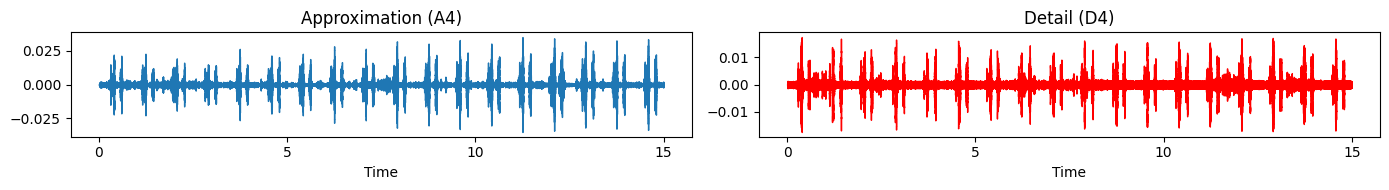

Approximation (A4):


Detail (D4):


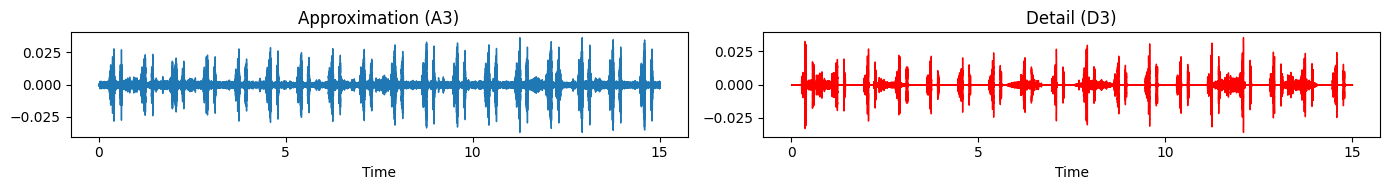

Approximation (A3):


Detail (D3):


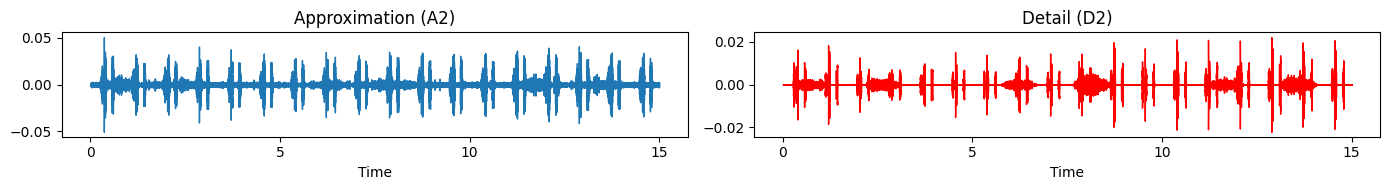

Approximation (A2):


Detail (D2):


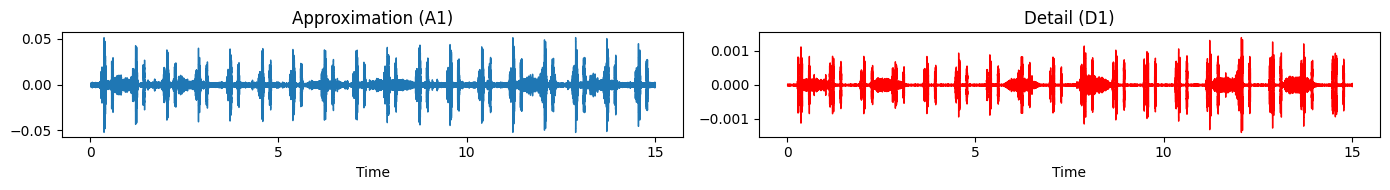

Approximation (A1):


Detail (D1):


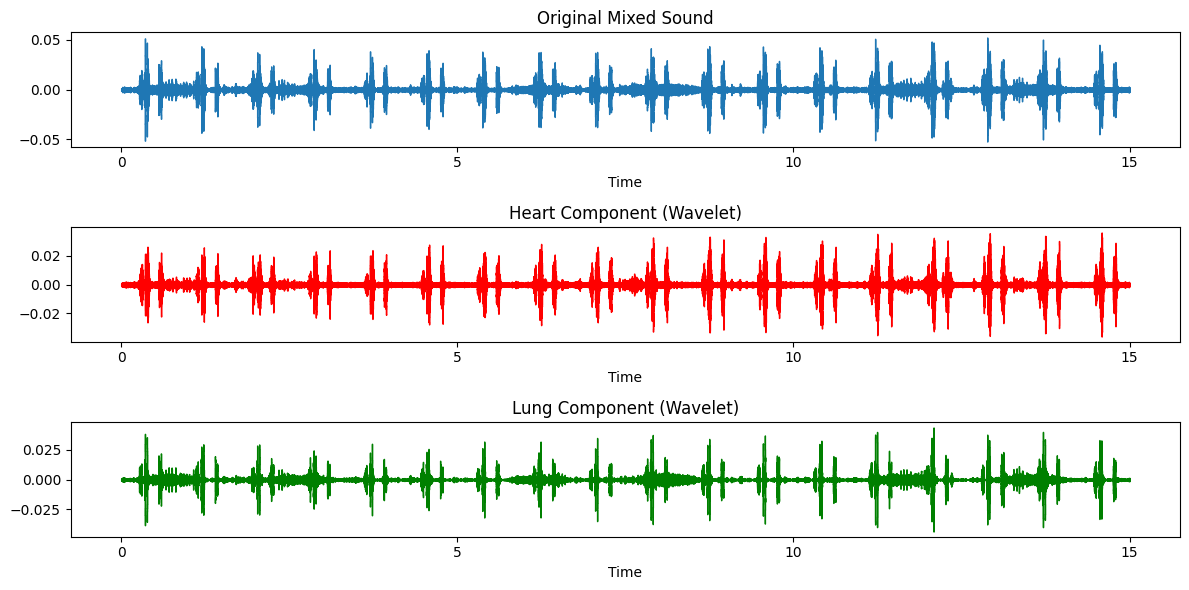

Heart Component (playback):


Lung Component (playback):


In [10]:
import pywt

# Use DWT to separate heart (short, repetitive) and lung (longer, smoother) components
wavelet = 'db10'
level = 5  # Adjust this

coeffs = pywt.wavedec(mixed_audio, wavelet, level=level)

for i in range(level):
    coeffs_approx = [np.copy(coeffs[0])] + [np.zeros_like(c) for c in coeffs[1:]]
    for j in range(1, i + 1):
        coeffs_approx[j] = np.copy(coeffs[j])
    approx_signal = pywt.waverec(coeffs_approx, wavelet)
    coeffs_detail = [np.zeros_like(coeffs[0])] + [np.zeros_like(c) for c in coeffs[1:]]
    coeffs_detail[i + 1] = np.copy(coeffs[i + 1])
    detail_signal = pywt.waverec(coeffs_detail, wavelet)

    plt.figure(figsize=(14, 2))
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(approx_signal, sr=sr)
    plt.title(f"Approximation (A{level - i})")
    plt.tight_layout()
    plt.subplot(1, 2, 2)
    librosa.display.waveshow(detail_signal, sr=sr, color='r')
    plt.title(f"Detail (D{level - i})")
    plt.tight_layout()
    plt.show()

    print(f"Approximation (A{level - i}):")
    display(Audio(approx_signal, rate=sr))
    print(f"Detail (D{level - i}):")
    display(Audio(detail_signal, rate=sr))

heart_coeffs = [np.zeros_like(c) for c in coeffs]
for i in range(1, 3):
    heart_coeffs[i] = coeffs[i]

heart_wavelet = pywt.waverec(heart_coeffs, wavelet)

lung_coeffs = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
for i in range(3, len(coeffs)):
    lung_coeffs[i] = coeffs[i]

lung_wavelet = pywt.waverec(lung_coeffs, wavelet)

plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
librosa.display.waveshow(mixed_audio, sr=sr)
plt.title("Original Mixed Sound")
plt.subplot(3, 1, 2)
librosa.display.waveshow(heart_wavelet, sr=sr, color='r')
plt.title("Heart Component (Wavelet)")
plt.subplot(3, 1, 3)
librosa.display.waveshow(lung_wavelet, sr=sr, color='g')
plt.title("Lung Component (Wavelet)")
plt.tight_layout()
plt.show()

print("Heart Component (playback):")
display(Audio(heart_wavelet, rate=sr))
print("Lung Component (playback):")
display(Audio(lung_wavelet, rate=sr))

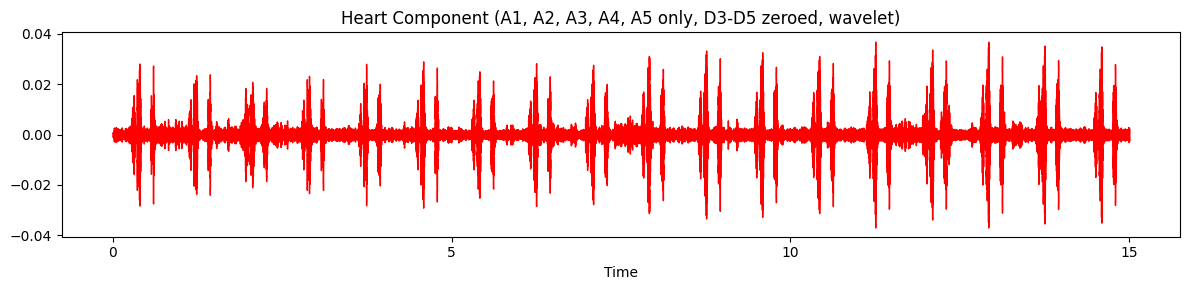

Heart Component (A1, A2, A3, A4, A5 only, D3-D5 zeroed, playback):


In [11]:
# Zeroing out the corresponding detail coefficients D3, D4, D5 (coeffs[3], coeffs[2], coeffs[1])
# Keeping only approximation (A5), and add A1 and A2 (coeffs[1], coeffs[2])
heart_coeffs_a1a2a3a4a5 = [np.copy(coeffs[0])] + [np.copy(coeffs[1]), np.copy(coeffs[2])] + [np.zeros_like(c) for c in coeffs[3:]]
heart_a1a2a3a4a5 = pywt.waverec(heart_coeffs_a1a2a3a4a5, wavelet)

plt.figure(figsize=(12, 3))
librosa.display.waveshow(heart_a1a2a3a4a5, sr=sr, color='r')
plt.title("Heart Component (A1, A2, A3, A4, A5 only, D3-D5 zeroed, wavelet)")
plt.tight_layout()
plt.show()

print("Heart Component (A1, A2, A3, A4, A5 only, D3-D5 zeroed, playback):")
display(Audio(heart_a1a2a3a4a5, rate=sr))


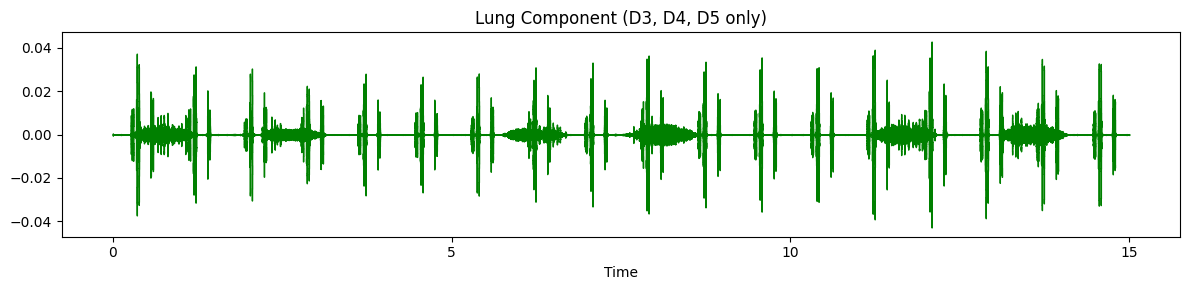

Lung Component (D3, D4, D5 only, playback):


In [12]:
from scipy.signal import medfilt

# For lungs: Zeroing out approximation and lower-level details (A5, D1, D2), keep only D3, D4, D5 (coeffs[3], coeffs[4], coeffs[5])
lung_coeffs_d3d4d5 = [np.zeros_like(coeffs[0]), np.zeros_like(coeffs[1]), np.zeros_like(coeffs[2]), 
                      np.copy(coeffs[3]), np.copy(coeffs[4]), np.copy(coeffs[5])]
lung_d3d4d5 = pywt.waverec(lung_coeffs_d3d4d5, wavelet)


plt.figure(figsize=(12, 3))
librosa.display.waveshow(lung_d3d4d5, sr=sr, color='g')
plt.title("Lung Component (D3, D4, D5 only)")
plt.tight_layout()
plt.show()

print("Lung Component (D3, D4, D5 only, playback):")
display(Audio(lung_d3d4d5, rate=sr))
